![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Proyecto 2 - Clasificación de género de películas

El propósito de este proyecto es que puedan poner en práctica, en sus respectivos grupos de trabajo, sus conocimientos sobre técnicas de preprocesamiento, modelos predictivos de NLP, y la disponibilización de modelos. Para su desarrollo tengan en cuenta las instrucciones dadas en la "Guía del proyecto 2: Clasificación de género de películas"

**Entrega**: La entrega del proyecto deberán realizarla durante la semana 8. Sin embargo, es importante que avancen en la semana 7 en el modelado del problema y en parte del informe, tal y como se les indicó en la guía.

Para hacer la entrega, deberán adjuntar el informe autocontenido en PDF a la actividad de entrega del proyecto que encontrarán en la semana 8, y subir el archivo de predicciones a la [competencia de Kaggle](https://www.kaggle.com/t/29c44fce98c747f2a1dfdaf29d4c4965).

## Datos para la predicción de género en películas

![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/moviegenre.png)

En este proyecto se usará un conjunto de datos de géneros de películas. Cada observación contiene el título de una película, su año de lanzamiento, la sinopsis o plot de la película (resumen de la trama) y los géneros a los que pertenece (una película puede pertenercer a más de un género). Por ejemplo:
- Título: 'How to Be a Serial Killer'
- Plot: 'A serial killer decides to teach the secrets of his satisfying career to a video store clerk.'
- Generos: 'Comedy', 'Crime', 'Horror'

La idea es que usen estos datos para predecir la probabilidad de que una película pertenezca, dada la sinopsis, a cada uno de los géneros.

Agradecemos al profesor Fabio González, Ph.D. y a su alumno John Arevalo por proporcionar este conjunto de datos. Ver https://arxiv.org/abs/1702.01992

## Ejemplo predicción conjunto de test para envío a Kaggle
En esta sección encontrarán el formato en el que deben guardar los resultados de la predicción para que puedan subirlos a la competencia en Kaggle.

In [44]:
import warnings
warnings.filterwarnings('ignore')

In [45]:
# Importación librerías
import pandas as pd
import os
import re
import ast
import numpy as np
import matplotlib.pyplot as plt
import joblib
%matplotlib inline

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

In [46]:
# Carga de datos de archivo .csv
dataTraining = pd.read_csv('https://github.com/albahnsen/MIAD_ML_and_NLP/raw/main/datasets/dataTraining.zip', encoding='UTF-8', index_col=0)
dataTesting = pd.read_csv('https://github.com/albahnsen/MIAD_ML_and_NLP/raw/main/datasets/dataTesting.zip', encoding='UTF-8', index_col=0)

In [47]:
# Visualización datos de entrenamiento
dataTraining.head()

,year,title,plot,genres,rating
3107,2003,Most,most is the story of a single father who takes...,"['Short', 'Drama']",8.0
900,2008,How to Be a Serial Killer,a serial killer decides to teach the secrets o...,"['Comedy', 'Crime', 'Horror']",5.6
6724,1941,A Woman's Face,"in sweden , a female blackmailer with a disfi...","['Drama', 'Film-Noir', 'Thriller']",7.2
4704,1954,Executive Suite,"in a friday afternoon in new york , the presi...",['Drama'],7.4
2582,1990,Narrow Margin,"in los angeles , the editor of a publishing h...","['Action', 'Crime', 'Thriller']",6.6


In [48]:
# Visualización datos de test
dataTesting.head()

,year,title,plot
1,1999,Message in a Bottle,"who meets by fate , shall be sealed by fate ...."
4,1978,Midnight Express,"the true story of billy hayes , an american c..."
5,1996,Primal Fear,martin vail left the chicago da ' s office to ...
6,1950,Crisis,husband and wife americans dr . eugene and mr...
7,1959,The Tingler,the coroner and scientist dr . warren chapin ...


## 1. EDA

Miramos cuántos géneros tiene cada peli, qué tan balanceadas están las clases y largo de los plots.

Géneros por película (estadísticas):
count    7895.000000
mean        2.732869
std         1.181396
min         1.000000
25%         2.000000
50%         3.000000
75%         3.000000
max         9.000000
Name: genres_list, dtype: float64


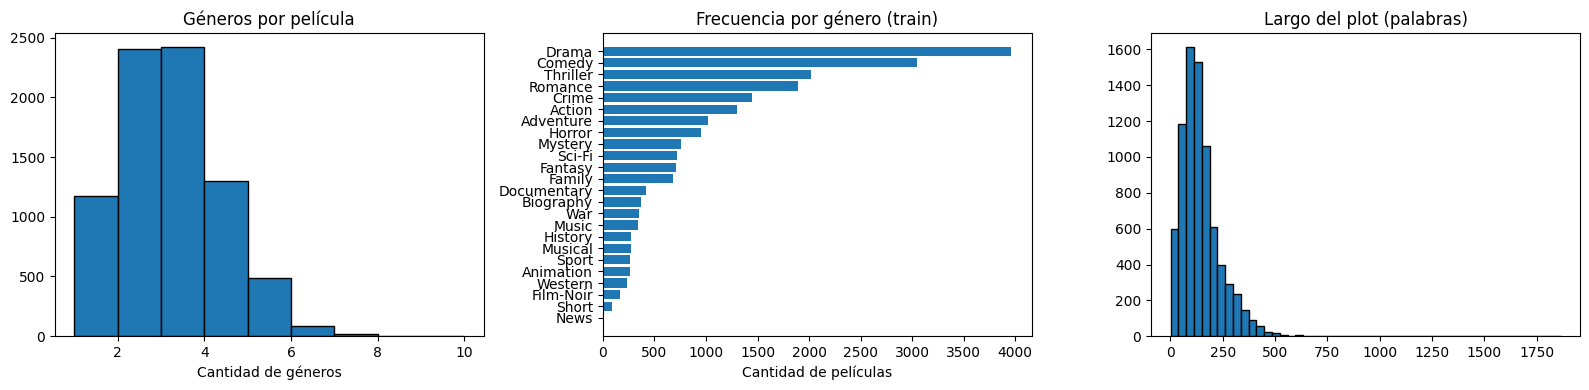


Largo medio del plot: 145 palabras
Total películas: 7895

Frecuencia por género:
      genre  count
      Drama   3965
     Comedy   3046
   Thriller   2024
    Romance   1892
      Crime   1447
     Action   1303
  Adventure   1024
     Horror    954
    Mystery    759
     Sci-Fi    723
    Fantasy    707
     Family    682
Documentary    419
  Biography    373
        War    348
      Music    341
    History    273
    Musical    271
      Sport    261
  Animation    260
    Western    237
  Film-Noir    168
      Short     92
       News      7


In [49]:
# parser robusto (literal_eval falla limpio si algo viene mal-formado)
def _safe_parse_genres(x):
    try:
        out = ast.literal_eval(x) if isinstance(x, str) else x
        return list(out) if isinstance(out, (list, tuple)) else []
    except (ValueError, SyntaxError):
        return []

dataTraining['genres_list'] = dataTraining['genres'].map(_safe_parse_genres)

genres_per_movie = dataTraining['genres_list'].map(len)
print('Géneros por película (estadísticas):')
print(genres_per_movie.describe())

from collections import Counter
genre_counts = Counter(g for genres in dataTraining['genres_list'] for g in genres)
genre_df = pd.DataFrame(genre_counts.most_common(), columns=['genre', 'count'])

plot_lengths = dataTraining['plot'].str.split().map(len)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(genres_per_movie, bins=range(1, genres_per_movie.max() + 2), edgecolor='black')
axes[0].set_title('Géneros por película')
axes[0].set_xlabel('Cantidad de géneros')

axes[1].barh(genre_df['genre'], genre_df['count'])
axes[1].set_title('Frecuencia por género (train)')
axes[1].set_xlabel('Cantidad de películas')
axes[1].invert_yaxis()

axes[2].hist(plot_lengths, bins=50, edgecolor='black')
axes[2].set_title('Largo del plot (palabras)')

plt.tight_layout()
plt.show()

print()
print('Largo medio del plot:', round(plot_lengths.mean()), 'palabras')
print('Total películas:', len(dataTraining))
print()
print('Frecuencia por género:')
print(genre_df.to_string(index=False))

## 2. Limpieza del texto

Función para normalizar el plot antes de vectorizar.

In [50]:
def clean_text(text):
    """Limpieza básica del plot: HTML → lower → sin dígitos/puntuación → espacios colapsados."""
    if not isinstance(text, str):
        return ""
    text = re.sub(r'<[^>]+>', ' ', text)       # quitar etiquetas HTML
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)      # solo letras y espacios
    text = re.sub(r'\s+', ' ', text).strip()   # colapsar espacios
    return text

dataTraining['plot_clean'] = dataTraining['plot'].map(clean_text)
dataTesting['plot_clean']  = dataTesting['plot'].map(clean_text)

print("Ejemplo original :")
print(dataTraining['plot'].iloc[0][:200])
print("\nEjemplo limpio   :")
print(dataTraining['plot_clean'].iloc[0][:200])

Ejemplo original :
most is the story of a single father who takes his eight year - old son to work with him at the railroad drawbridge where he is the bridge tender .  a day before ,  the boy meets a woman boarding a tr

Ejemplo limpio   :
most is the story of a single father who takes his eight year old son to work with him at the railroad drawbridge where he is the bridge tender a day before the boy meets a woman boarding a train a dr


## 3. Variable objetivo (multi-etiqueta)

In [51]:
le = MultiLabelBinarizer()
y_genres = np.array(le.fit_transform(dataTraining['genres_list']))

# Orden de columnas que pide Kaggle
cols = ['p_Action', 'p_Adventure', 'p_Animation', 'p_Biography', 'p_Comedy', 'p_Crime',
        'p_Documentary', 'p_Drama', 'p_Family', 'p_Fantasy', 'p_Film-Noir', 'p_History',
        'p_Horror', 'p_Music', 'p_Musical', 'p_Mystery', 'p_News', 'p_Romance',
        'p_Sci-Fi', 'p_Short', 'p_Sport', 'p_Thriller', 'p_War', 'p_Western']

# Sanity check: el orden del binarizador tiene que coincidir con el de Kaggle
assert list(le.classes_) == [c[2:] for c in cols]
print('Clases:', list(le.classes_))
print('y_genres:', y_genres.shape)

Clases: ['Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'News', 'Romance', 'Sci-Fi', 'Short', 'Sport', 'Thriller', 'War', 'Western']
y_genres: (7895, 24)


## 4. Split 80/20 + TF-IDF

Split primero, fit del TF-IDF solo en train (si no, leakage).

In [52]:
# split por índices primero (para no contaminar el TF-IDF con val)
idx_all = np.arange(len(dataTraining))
idx_train, idx_val = train_test_split(idx_all, test_size=0.20, random_state=42)

texts_train = dataTraining['plot_clean'].iloc[idx_train]
texts_val   = dataTraining['plot_clean'].iloc[idx_val]
y_train_genres = y_genres[idx_train]
y_val_genres   = y_genres[idx_val]

# TF-IDF: unigramas + bigramas. fit solo en train.
vect = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=50000,
    sublinear_tf=True,
    stop_words='english',
)
X_train = vect.fit_transform(texts_train)
X_val   = vect.transform(texts_val)

print('Train:', X_train.shape, ' Val:', X_val.shape)

Train: (6316, 41665)  Val: (1579, 41665)


## 5. Modelo base: OneVsRest + LogReg

In [53]:
# n_jobs=1 a propósito (con sparse + loky daba problemas de memory map read-only)
clf = OneVsRestClassifier(
    LogisticRegression(C=1.0, max_iter=1000, solver='liblinear'),
    n_jobs=1,
)
clf.fit(X_train, y_train_genres)
print('Modelo entrenado.', len(clf.estimators_), 'clasificadores binarios.')

Modelo entrenado. 24 clasificadores binarios.


## 6. Evaluación del modelo base

In [54]:
y_pred_val = clf.predict_proba(X_val)

auc_macro_v1 = roc_auc_score(y_val_genres, y_pred_val, average='macro')
print('ROC AUC macro:', round(auc_macro_v1, 4))

auc_per_class = roc_auc_score(y_val_genres, y_pred_val, average=None)
auc_df = pd.DataFrame({'genre': le.classes_, 'AUC': auc_per_class}).sort_values('AUC')
print()
print('AUC por género (peor a mejor):')
print(auc_df.to_string(index=False))

# F1 con threshold default — sirve para ver qué tan duro pega th=0.5 a clases raras
y_pred_binary = (y_pred_val >= 0.5).astype(int)
f1_macro = f1_score(y_val_genres, y_pred_binary, average='macro', zero_division=0)
f1_micro = f1_score(y_val_genres, y_pred_binary, average='micro', zero_division=0)
print()
print('F1 macro (th=0.5):', round(f1_macro, 4))
print('F1 micro (th=0.5):', round(f1_micro, 4))

ROC AUC macro: 0.8945

AUC por género (peor a mejor):
      genre      AUC
      Drama 0.770168
     Comedy 0.822867
    Romance 0.833665
    Musical 0.840226
   Thriller 0.845895
    Fantasy 0.858629
  Film-Noir 0.864519
    Mystery 0.867831
  Biography 0.875282
    History 0.881775
  Adventure 0.887684
     Action 0.887732
      Short 0.891345
      Crime 0.900381
      Music 0.900961
     Horror 0.914105
     Family 0.915825
     Sci-Fi 0.921775
  Animation 0.926410
      Sport 0.951961
        War 0.953419
Documentary 0.971176
    Western 0.986630
       News 0.998733

F1 macro (th=0.5): 0.1263
F1 micro (th=0.5): 0.3896


## 7. Baseline RandomForest para comparar

In [55]:
# mismo split que arriba, CountVectorizer simple + RF
vect_base    = CountVectorizer(max_features=1000)
X_train_base = vect_base.fit_transform(dataTraining['plot_clean'].iloc[idx_train])
X_val_base   = vect_base.transform(dataTraining['plot_clean'].iloc[idx_val])

clf_base = OneVsRestClassifier(
    RandomForestClassifier(n_jobs=1, n_estimators=100, max_depth=10, random_state=42)
)
clf_base.fit(X_train_base, y_train_genres)
y_pred_base = clf_base.predict_proba(X_val_base)
auc_baseline = roc_auc_score(y_val_genres, y_pred_base, average='macro')

print(f'Baseline RF:  {auc_baseline:.4f}')
print(f'TF-IDF + LR:  {auc_macro_v1:.4f}')
print(f'Diferencia:  +{auc_macro_v1 - auc_baseline:.4f}')

Baseline RF:  0.7922
TF-IDF + LR:  0.8945
Diferencia:  +0.1024


## 8. Feature engineering

Vamos a probar tres cosas extra encima del TF-IDF a ver si suman:

1. Split estratificado por etiqueta con `IterativeStratification` para que clases raras (News, Western) tengan representación en val.
2. Sentimiento del plot con VADER.
3. Top 10 keywords por género vía chi2 (solo en train) como flags binarios → 240 features extras.

Más adelante (sección 10) comparamos contra el modelo base y vemos cuál combinación gana.

In [56]:
from skmultilearn.model_selection import IterativeStratification

# IterativeStratification.split() devuelve (train, test) — ojo con el orden.
# Con sample_distribution_per_fold=[0.2, 0.8] el primer test es el 20% (= val).
stratifier = IterativeStratification(n_splits=2, order=1,
                                     sample_distribution_per_fold=[0.2, 0.8])
idx_train_v2, idx_val_v2 = next(stratifier.split(np.zeros(len(y_genres)), y_genres))

y_train_v2 = y_genres[idx_train_v2]
y_val_v2   = y_genres[idx_val_v2]

print('Train:', len(idx_train_v2), ' Val:', len(idx_val_v2))
print()
print('Cómo quedaron las clases raras en val:')
rep = pd.DataFrame({
    'genre': le.classes_,
    'total': y_genres.sum(axis=0),
    'train': y_train_v2.sum(axis=0),
    'val':   y_val_v2.sum(axis=0),
}).sort_values('total').head(10)
print(rep.to_string(index=False))

Train: 6326  Val: 1569

Cómo quedaron las clases raras en val:
    genre  total  train  val
     News      7      6    1
    Short     92     74   18
Film-Noir    168    134   34
  Western    237    190   47
Animation    260    214   46
    Sport    261    209   52
  Musical    271    222   49
  History    273    234   39
    Music    341    276   65
      War    348    268   80


In [57]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Lo aplicamos sobre el plot crudo (VADER usa mayúsculas y puntuación).
sia = SentimentIntensityAnalyzer()
dataTraining['sent_compound'] = dataTraining['plot'].map(lambda t: sia.polarity_scores(t)['compound'])
dataTesting['sent_compound']  = dataTesting['plot'].map(lambda t: sia.polarity_scores(t)['compound'])

print('Sentimiento (train) → media={:.3f}, std={:.3f}, rango=[{:.2f}, {:.2f}]'.format(
    dataTraining['sent_compound'].mean(),
    dataTraining['sent_compound'].std(),
    dataTraining['sent_compound'].min(),
    dataTraining['sent_compound'].max(),
))

Sentimiento (train) → media=-0.033, std=0.747, rango=[-1.00, 1.00]


In [58]:
from sklearn.feature_selection import chi2

texts_train_v2 = dataTraining['plot_clean'].iloc[idx_train_v2].values
texts_val_v2   = dataTraining['plot_clean'].iloc[idx_val_v2].values

# Para elegir keywords usamos un CountVectorizer aparte de unigramas (no TF-IDF).
kw_vect = CountVectorizer(ngram_range=(1, 1), min_df=2, max_features=20000,
                          stop_words='english')
X_train_kw = kw_vect.fit_transform(texts_train_v2)
vocab_kw = np.array(kw_vect.get_feature_names_out())

K = 10  # cuántas keywords por género
genre_keywords = {}
for g_idx, g in enumerate(le.classes_):
    chi2_scores, _ = chi2(X_train_kw, y_train_v2[:, g_idx])
    top_idx = np.argsort(-chi2_scores)[:K]
    genre_keywords[g] = vocab_kw[top_idx].tolist()

print(f'Total slots: {24 * K} | tokens únicos:',
      len({kw for kws in genre_keywords.values() for kw in kws}))
print()
for g in ['Horror', 'Comedy', 'Western', 'News', 'War']:
    print(f'  {g:11s} →', genre_keywords[g])

Total slots: 240 | tokens únicos: 187

  Horror      → ['vampire', 'horror', 'dr', 'house', 'evil', 'blood', 'vampires', 'zombies', 'killer', 'zombie']
  Comedy      → ['comedy', 'wedding', 'harold', 'war', 'death', 'killed', 'murder', 'big', 'best', 'comic']
  Western     → ['west', 'indians', 'cattle', 'rancher', 'outlaws', 'outlaw', 'cavalry', 'custer', 'stagecoach', 'apache']
  News        → ['columbine', 'reconstruction', 'tents', 'loggerheads', 'timely', 'euphoria', 'click', 'elf', 'fascinating', 'extremes']
  War         → ['war', 'japanese', 'army', 'germans', 'german', 'soldiers', 'allied', 'platoon', 'troops', 'ii']


In [59]:
from scipy.sparse import hstack, csr_matrix

# matriz binaria de keywords por película
def build_kw_matrix(texts, kw_dict, classes_order):
    rows = []
    for txt in texts:
        toks = set(txt.split())
        row = [1 if kw in toks else 0 for g in classes_order for kw in kw_dict[g]]
        rows.append(row)
    return csr_matrix(np.array(rows, dtype=np.int8))

# TF-IDF de nuevo, ahora con el split estratificado
vect_v2 = TfidfVectorizer(
    ngram_range=(1, 2), min_df=2, max_df=0.95,
    max_features=50000, sublinear_tf=True, stop_words='english',
)
X_train_tfidf = vect_v2.fit_transform(texts_train_v2)
X_val_tfidf   = vect_v2.transform(texts_val_v2)

sent_train = dataTraining['sent_compound'].iloc[idx_train_v2].values.reshape(-1, 1)
sent_val   = dataTraining['sent_compound'].iloc[idx_val_v2].values.reshape(-1, 1)

kw_train = build_kw_matrix(texts_train_v2, genre_keywords, list(le.classes_))
kw_val   = build_kw_matrix(texts_val_v2,   genre_keywords, list(le.classes_))

# combinaciones para la ablación
X_train_sent  = hstack([X_train_tfidf, csr_matrix(sent_train)]).tocsr()
X_val_sent    = hstack([X_val_tfidf,   csr_matrix(sent_val)]).tocsr()
X_train_kwbin = hstack([X_train_tfidf, kw_train]).tocsr()
X_val_kwbin   = hstack([X_val_tfidf,   kw_val]).tocsr()
X_train_full  = hstack([X_train_tfidf, csr_matrix(sent_train), kw_train]).tocsr()
X_val_full    = hstack([X_val_tfidf,   csr_matrix(sent_val),   kw_val]).tocsr()

print('Solo TF-IDF:    ', X_train_tfidf.shape)
print('+ sentimiento:  ', X_train_sent.shape)
print('+ keywords:     ', X_train_kwbin.shape)
print('TF-IDF+sent+kw: ', X_train_full.shape)

Solo TF-IDF:     (6326, 41722)
+ sentimiento:   (6326, 41723)
+ keywords:      (6326, 41962)
TF-IDF+sent+kw:  (6326, 41963)


## 9. ¿Tienen señal las features nuevas?

Antes de meterlas al modelo miramos si correlacionan algo con los géneros.

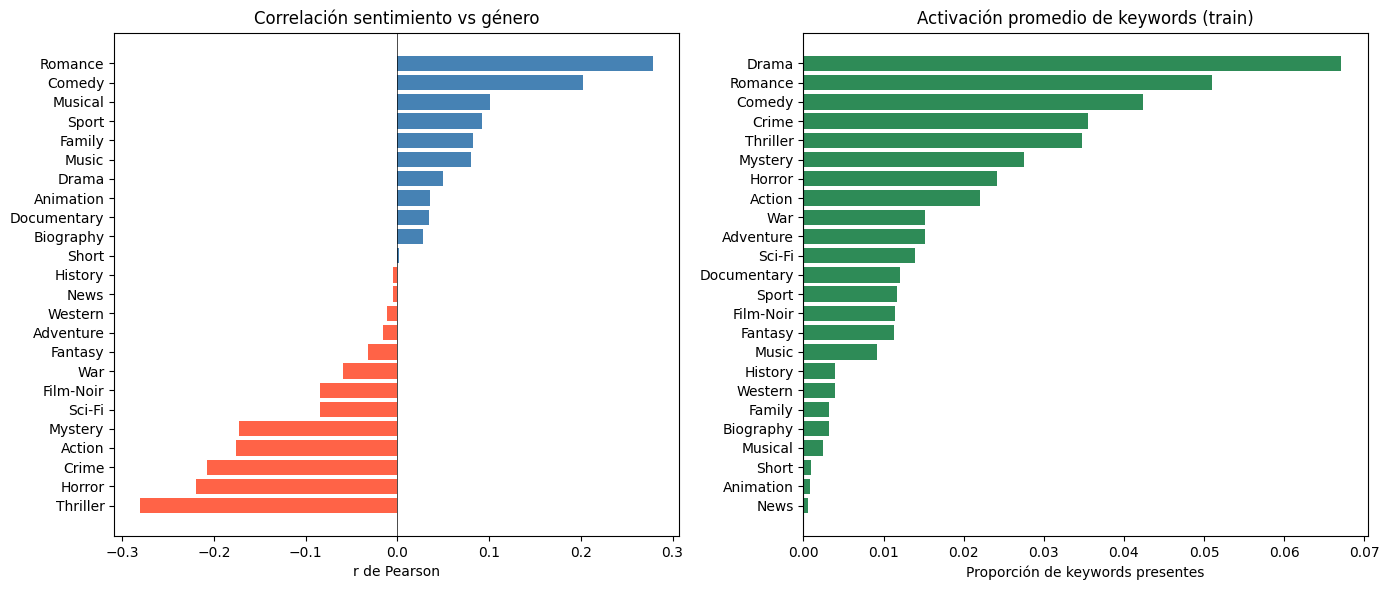

Géneros más negativos:
   genre  pearson_r
Thriller  -0.280723
  Horror  -0.219400
   Crime  -0.207580

Géneros más positivos:
  genre  pearson_r
Musical   0.100521
 Comedy   0.201953
Romance   0.278548


In [60]:
# Correlación sentimiento - género (en train)
sent_arr = dataTraining['sent_compound'].iloc[idx_train_v2].values
corrs = [(g, np.corrcoef(sent_arr, y_train_v2[:, g_idx])[0, 1])
         for g_idx, g in enumerate(le.classes_)]
corr_df = pd.DataFrame(corrs, columns=['genre', 'pearson_r']).sort_values('pearson_r')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(corr_df['genre'], corr_df['pearson_r'],
             color=['tomato' if r < 0 else 'steelblue' for r in corr_df['pearson_r']])
axes[0].axvline(0, color='black', lw=0.5)
axes[0].set_title('Correlación sentimiento vs género')
axes[0].set_xlabel('r de Pearson')

# Tasa media de activación de las keywords binarias
n_per_genre = K
activation = kw_train.toarray().reshape(kw_train.shape[0], len(le.classes_), n_per_genre).mean(axis=(0, 2))
act_df = pd.DataFrame({'genre': le.classes_, 'mean_active': activation}).sort_values('mean_active')
axes[1].barh(act_df['genre'], act_df['mean_active'], color='seagreen')
axes[1].set_title('Activación promedio de keywords (train)')
axes[1].set_xlabel('Proporción de keywords presentes')

plt.tight_layout()
plt.show()

print('Géneros más negativos:')
print(corr_df.head(3).to_string(index=False))
print()
print('Géneros más positivos:')
print(corr_df.tail(3).to_string(index=False))

## 10. Comparación de modelos

Probamos varias combinaciones con el mismo split estratificado y nos quedamos con la mejor según AUC macro.

| Variante | Features | Clasificador |
|---|---|---|
| baseline | TF-IDF | LogReg sin class_weight |
| v2a | TF-IDF | LogReg + class_weight='balanced' |
| v2b-sent | TF-IDF + sentimiento | LogReg balanced |
| v2b-kw | TF-IDF + keywords | LogReg balanced |
| v2b | TF-IDF + sent + kw | LogReg balanced |
| v2c | TF-IDF + sent + kw | LinearSVC calibrado balanced |

In [61]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

def fit_eval(X_tr, X_va, name, clf):
    clf.fit(X_tr, y_train_v2)
    p = clf.predict_proba(X_va)
    auc = roc_auc_score(y_val_v2, p, average='macro')
    return {'name': name, 'auc_macro': auc, 'clf': clf, 'proba_val': p}

def lr_balanced():
    return OneVsRestClassifier(
        LogisticRegression(C=1.0, max_iter=1000, solver='liblinear', class_weight='balanced'),
        n_jobs=1,
    )

# baseline (sin class_weight) re-entrenado en el split estratificado nuevo
res_base = fit_eval(X_train_tfidf, X_val_tfidf, 'baseline (LR sin balance)',
    OneVsRestClassifier(
        LogisticRegression(C=1.0, max_iter=1000, solver='liblinear'),
        n_jobs=1,
    ))

res_v2a      = fit_eval(X_train_tfidf, X_val_tfidf, 'v2a  LR balanced',          lr_balanced())
res_v2b_sent = fit_eval(X_train_sent,  X_val_sent,  'v2b  + sentimiento',        lr_balanced())
res_v2b_kw   = fit_eval(X_train_kwbin, X_val_kwbin, 'v2b  + keywords',           lr_balanced())
res_v2b      = fit_eval(X_train_full,  X_val_full,  'v2b  + sent + keywords',    lr_balanced())

# LinearSVC necesita CalibratedClassifierCV para tener predict_proba.
# cv=2 porque con cv=3 falla por clases muy raras (News tiene 5 ejemplos en train).
svc = LinearSVC(C=1.0, class_weight='balanced', max_iter=2000)
cal = CalibratedClassifierCV(svc, cv=2, method='sigmoid')
res_v2c = fit_eval(X_train_full, X_val_full, 'v2c  LinearSVC calibrado',
                   OneVsRestClassifier(cal, n_jobs=1))

results = [res_base, res_v2a, res_v2b_sent, res_v2b_kw, res_v2b, res_v2c]
summary = pd.DataFrame({
    'modelo':    [r['name'] for r in results],
    'AUC macro': [r['auc_macro'] for r in results],
})
summary['delta'] = summary['AUC macro'] - summary['AUC macro'].iloc[0]
print(summary.to_string(index=False))

                   modelo  AUC macro     delta
baseline (LR sin balance)   0.900163  0.000000
         v2a  LR balanced   0.900958  0.000796
       v2b  + sentimiento   0.892674 -0.007489
          v2b  + keywords   0.837990 -0.062173
   v2b  + sent + keywords   0.835504 -0.064659
 v2c  LinearSVC calibrado   0.832089 -0.068074


In [62]:
best = max(results, key=lambda r: r['auc_macro'])
print(f"Ganador: {best['name']} (AUC macro = {best['auc_macro']:.4f})")

# AUC por género del ganador vs el baseline
auc_per_class_best = roc_auc_score(y_val_v2, best['proba_val'],     average=None)
auc_per_class_base = roc_auc_score(y_val_v2, res_base['proba_val'], average=None)
auc_genre_df = pd.DataFrame({
    'genre':       le.classes_,
    'baseline':    auc_per_class_base,
    'ganador':     auc_per_class_best,
})
auc_genre_df['delta'] = auc_genre_df['ganador'] - auc_genre_df['baseline']
auc_genre_df = auc_genre_df.sort_values('baseline')
print()
print('AUC por género:')
print(auc_genre_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Ganador: v2a  LR balanced (AUC macro = 0.9010)

AUC por género:
      genre  baseline  ganador   delta
      Drama    0.7775   0.7775  0.0000
     Comedy    0.8183   0.8185  0.0002
    Romance    0.8396   0.8394 -0.0002
  Biography    0.8542   0.8558  0.0016
   Thriller    0.8585   0.8580 -0.0004
  Adventure    0.8686   0.8701  0.0014
    Musical    0.8703   0.8693 -0.0010
    Mystery    0.8833   0.8810 -0.0023
     Action    0.8843   0.8835 -0.0008
  Film-Noir    0.8859   0.8863  0.0004
      Short    0.8872   0.8848 -0.0024
    Fantasy    0.8877   0.8862 -0.0015
    History    0.8926   0.8987  0.0060
     Family    0.9014   0.9013 -0.0001
      Crime    0.9115   0.9107 -0.0008
      Music    0.9202   0.9214  0.0012
     Sci-Fi    0.9226   0.9251  0.0025
  Animation    0.9260   0.9273  0.0013
     Horror    0.9444   0.9448  0.0004
      Sport    0.9631   0.9676  0.0045
Documentary    0.9717   0.9729  0.0012
    Western    0.9755   0.9779  0.0024
        War    0.9756   0.9776  0.0019


## 11. Threshold óptimo por género

Con threshold 0.5 el F1 para clases raras es horrible. Buscamos por brute force el umbral que maximiza F1 en val, género por género.

In [63]:
best_proba_val = best['proba_val']

# Por cada género buscamos el threshold que maximiza F1
thresholds = np.linspace(0.01, 0.99, 99)
best_thresholds = np.full(len(le.classes_), 0.5)
f1_per_class    = np.zeros(len(le.classes_))

for g_idx in range(len(le.classes_)):
    y_true_g  = y_val_v2[:, g_idx]
    y_proba_g = best_proba_val[:, g_idx]
    best_f1 = 0.0
    for t in thresholds:
        f1 = f1_score(y_true_g, (y_proba_g >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_thresholds[g_idx] = f1, t
    f1_per_class[g_idx] = best_f1

y_pred_tuned = (best_proba_val >= best_thresholds).astype(int)
y_pred_05    = (best_proba_val >= 0.5).astype(int)

print('F1 macro:  th=0.5 ->', round(f1_score(y_val_v2, y_pred_05,    average='macro', zero_division=0), 4),
      ' | tunneado ->',      round(f1_score(y_val_v2, y_pred_tuned, average='macro', zero_division=0), 4))
print('F1 micro:  th=0.5 ->', round(f1_score(y_val_v2, y_pred_05,    average='micro', zero_division=0), 4),
      ' | tunneado ->',      round(f1_score(y_val_v2, y_pred_tuned, average='micro', zero_division=0), 4))
print()
th_df = pd.DataFrame({'genre': le.classes_, 'threshold': best_thresholds, 'F1': f1_per_class})
th_df = th_df.sort_values('threshold')
print('Threshold óptimo (5 más bajos y 5 más altos):')
print(pd.concat([th_df.head(5), th_df.tail(5)]).to_string(index=False))

F1 macro:  th=0.5 -> 0.5231  | tunneado -> 0.5555
F1 micro:  th=0.5 -> 0.6289  | tunneado -> 0.6443

Threshold óptimo (5 más bajos y 5 más altos):
      genre  threshold       F1
       News       0.03 0.046512
      Short       0.31 0.400000
    Western       0.38 0.725275
      Drama       0.39 0.735086
  Film-Noir       0.39 0.271605
     Horror       0.51 0.708229
        War       0.53 0.708075
     Action       0.54 0.601113
Documentary       0.54 0.729560
    History       0.54 0.351351


## 12. Re-entrenamos el ganador con todo el training

El ganador fue `LR balanced + TF-IDF` (apenas +0.001 AUC sobre el baseline). El sentimiento y las keywords no ayudaron — las keywords incluso bajaron el AUC unas 5 décimas porque son redundantes con el TF-IDF.

Así que el modelo final es solo TF-IDF + `class_weight='balanced'`. Re-entrenamos con el 100% del training antes de generar el submission.

In [64]:
# El ganador solo usa TF-IDF. Refit con el 100% del training.
vect_final = TfidfVectorizer(
    ngram_range=(1, 2), min_df=2, max_df=0.95,
    max_features=50000, sublinear_tf=True, stop_words='english',
)
X_full_tfidf = vect_final.fit_transform(dataTraining['plot_clean'])

clf_final = OneVsRestClassifier(
    LogisticRegression(C=1.0, max_iter=1000, solver='liblinear', class_weight='balanced'),
    n_jobs=1,
)
clf_final.fit(X_full_tfidf, y_genres)
print('Modelo final entrenado.', X_full_tfidf.shape[1], 'features,', len(clf_final.estimators_), 'clases.')

Modelo final entrenado. 50000 features, 24 clases.


## 13. Submission para Kaggle

In [65]:
# Predicción en test (modelo final TF-IDF + LR balanced)
X_test_tfidf = vect_final.transform(dataTesting['plot_clean'])
y_pred_test = clf_final.predict_proba(X_test_tfidf)

submission = pd.DataFrame(y_pred_test, index=dataTesting.index, columns=cols)
submission.to_csv('submission.csv', index_label='ID')
print(f"submission.csv  →  {submission.shape[0]} filas × {submission.shape[1]} cols")
submission.head()

submission.csv  →  3383 filas × 24 cols


,p_Action,p_Adventure,p_Animation,p_Biography,p_Comedy,p_Crime,p_Documentary,p_Drama,p_Family,p_Fantasy,...,p_Musical,p_Mystery,p_News,p_Romance,p_Sci-Fi,p_Short,p_Sport,p_Thriller,p_War,p_Western
1,0.288717,0.187837,0.119689,0.147649,0.404369,0.265204,0.115012,0.540937,0.177068,0.395313,...,0.218222,0.316922,0.013888,0.769300,0.176916,0.101491,0.106738,0.316648,0.103504,0.134522
4,0.297076,0.130318,0.120353,0.691340,0.337835,0.540562,0.266895,0.817191,0.143560,0.067194,...,0.140041,0.151026,0.018832,0.241340,0.070950,0.071990,0.199797,0.443264,0.252190,0.087949
5,0.248199,0.076546,0.036132,0.255295,0.196128,0.872664,0.087727,0.778594,0.052381,0.099351,...,0.098744,0.792092,0.023387,0.326735,0.150174,0.042026,0.081996,0.764183,0.083264,0.075200
6,0.243879,0.249266,0.070490,0.302999,0.227905,0.180751,0.139373,0.685050,0.150955,0.168538,...,0.172090,0.364349,0.013811,0.326602,0.306950,0.037402,0.140539,0.512216,0.357135,0.104113
7,0.175921,0.206179,0.127058,0.099900,0.289775,0.291251,0.107949,0.381220,0.197593,0.447915,...,0.112580,0.323095,0.013082,0.320173,0.763688,0.076228,0.048028,0.560461,0.065082,0.087507


## 14. Guardamos los artefactos para la API

Lo que `api.py` carga al arrancar: el vectorizador, el clasificador, el binarizador y la lista de columnas.

In [66]:
joblib.dump(vect_final, 'tfidf_vectorizer.pkl')
joblib.dump(clf_final,  'genre_clf.pkl')
joblib.dump(le,         'mlb_genres.pkl')
joblib.dump(cols,       'output_columns.pkl')

print("Artefactos guardados:")
for f in ['tfidf_vectorizer.pkl', 'genre_clf.pkl', 'mlb_genres.pkl', 'output_columns.pkl']:
    size_mb = os.path.getsize(f) / 1e6 if os.path.exists(f) else 0
    print(f"  {f:25s} ({size_mb:.2f} MB)")

Artefactos guardados:
  tfidf_vectorizer.pkl      (2.02 MB)
  genre_clf.pkl             (9.61 MB)
  mlb_genres.pkl            (0.00 MB)
  output_columns.pkl        (0.00 MB)
